#### Synthetic data generation 
Generate evenly (neighborhood-wise) spaced geojson objects corresponding to a district in Barcelona. They should contain: 
- Geographic coordinates (within district polygon) (2)
- Neighborhood they belong to
- Hourly water consumption pattern as array (1)
Resulting list should be easily filterable in case lesser amount of points were to be necessary, for performance reasons.

##### (1) Generating per-point realistic hourly consumption patterns
- Find out avg water daily consumption rate in bcn.
    - Model with *average-daily-consumption-Gaussian* (N~(avg, std))
    - When deciding the average accumulated daily water consumption amount for a particular point, we will sample from the aforementioned distribution. (*) 
- Come up with per-point, pseudo-random consumption pdf curve based on intuitive consumption patterns (i.e. less consumption during nighttime etc.):
    - Model the consumption rate at each hour with a *per-hour-Gaussian*. E.g:
        - Morning and evening shower times have a higher mean and lower std. 
            - Subsequent consumptions that could be related to showers should be lowered.  
        - 4am should have lower mean and higher std.
        - Etc.
    - Normalizing by dividing each element by the sum of the array guarantees a pdf. 
    - Sample each timepoint according to aforementioned method. 
- Multiply per-hour pdf values by avg value (*) -> per-hour consumption for that particular data point.
    - Adding them together should naturally result in (*)

      

##### (2) Generating geospatial coordinates 
- Determine N based on nbh number
- For each nbh in district: 
    - Get nbh polygon coordinates 
    - Generate N points
    - Assign point coordinates + nbh name to point dict
    - Generate consumption array based on (1)

# (1)

In [1]:
import numpy as np

In [2]:
def generate_random_house_hold_daily_consumption_total():
    mean_family_n, std_family_n = 2.5, 1.5 
    family_n = np.random.normal(mean_family_n, std_family_n, 1).round()[0]
    family_n = max(1, family_n)

    # https://www.statista.com/statistics/801686/per-capita-daily-water-consumption-in-spain/
    # avg daily water consumption in spain 2018 (l)
    mean_cons, std_cons = 132, 15
    hh_daily_cons = np.random.normal(mean_cons, std_cons, 1).round(3)[0] * max(1, np.log(family_n)+1) # ponder by family number
    hh_daily_cons = max(10, hh_daily_cons) # to prevent negative values, although highly unlikely 

    # household daily consumption
    return hh_daily_cons, family_n

In [3]:
import matplotlib.pyplot as plt

In [4]:
hours = np.arange(1, 25)
base_scores = np.array([
    (1.5, 1), # 1
    (1, 1),   # 2 
    (0, 1),    
    (0, 1), 
    (0, 2), 
    (2, 2),
    (3, 2), 
    (4, 2), 
    (5, 1), 
    (5, 1), 
    (3, 2), 
    (2, 1), # 12
    (3, 1), 
    (3, 1), 
    (3, 1), 
    (1, 1), # 16
    (0, 1), 
    (2, 1),
    (3, 1), 
    (3, 1), # 20
    (4, 1), 
    (4, 1), 
    (3, 2), 
    (2, 1)
])

def generate_random_house_hold_daily_consumption_pdf():
    # plt.plot(hours, np.array(per_hour_scores)[:, 0])
    shift_schedule_prob = 0.2
    if np.random.rand() <= shift_schedule_prob:
        shift_pos_val = int(np.random.normal(2, 4.5, 1).round()[0])
        hh_base_scores = np.roll(base_scores, shift_pos_val, axis=0)
    else:
        hh_base_scores = base_scores

    hh_scores = []
    for hs in hh_base_scores: 
        mean, std = hs
        score = np.random.normal(mean, std, 1).round(2)[0]
        score = max(score, 0)
        hh_scores.append(score)

    # normalize to create pdf
    hh_consumption_pdf = hh_scores / np.sum(hh_scores)
    return hh_consumption_pdf

5.0 313.6779220157908 313.67792201579084


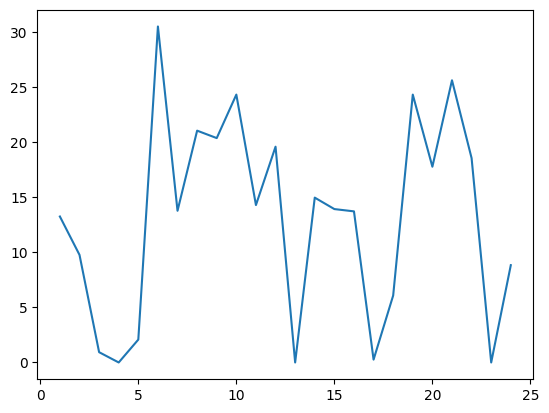

In [5]:
## test (1)
random_cons_total, family_n = generate_random_house_hold_daily_consumption_total()
random_cons_pdf = generate_random_house_hold_daily_consumption_pdf()
cons_pattern = random_cons_pdf * random_cons_total
plt.plot(hours, cons_pattern)
print(family_n, random_cons_total, np.sum(cons_pattern))

# (2)

In [6]:
from shapely.geometry import Point, Polygon
import geopandas as gpd
import pandas as pd


# https://www.matecdev.com/posts/random-points-in-polygon.html
def Random_Points_in_Bounds(polygon, number):   
    minx, miny, maxx, maxy = polygon.bounds
    x = np.random.uniform( minx, maxx, number )
    y = np.random.uniform( miny, maxy, number )
    return x, y

def random_points_in_nbh(nbh, n):
    nbh_coordinates = nbh['geometry']['coordinates'][0]
    nbh_polygon = Polygon(nbh_coordinates)
    polygon = nbh_polygon
    gdf_poly = gpd.GeoDataFrame(index=["myPoly"], geometry=[polygon])

    # Now, let’s create another GeoDataFrame with random points in the bounding box of our polygon.
    def spatial_join():
        x,y = Random_Points_in_Bounds(polygon, n)
        df = pd.DataFrame()
        df['points'] = list(zip(x,y))
        df['points'] = df['points'].apply(Point)
        gdf_points = gpd.GeoDataFrame(df, geometry='points')
        # And finally, we compute the spatial join to match points and polygons
        Sjoin = gpd.tools.sjoin(gdf_points, gdf_poly, predicate="within", how='left')
        # Keep points in "myPoly"
        pnts_in_poly = gdf_points[Sjoin.index_right=='myPoly']
        return pnts_in_poly

    pnts_in_nbh = spatial_join()
    while len(pnts_in_nbh) < n:
        pnts_in_nbh = pd.concat([pnts_in_nbh, spatial_join()])

    cord_list = [tp[1].values[0].coords[0] for tp in list(pnts_in_nbh.iterrows())][:n]
    
    return cord_list



# Putting it all together

In [7]:
import json

In [8]:
with open('../0301100100_UNITATS_ADM_POLIGONS_TRANSFORMED.json') as f:
        bcn_geojson = json.load(f)

In [9]:
districts = [f for f in bcn_geojson["features"] if f["properties"]["SCONJ_DESC"] == "Districte"]
nbhs = [f for f in bcn_geojson["features"] if f["properties"]["SCONJ_DESC"] == "Barri"]

In [10]:
districts_properties = [d["properties"] for d in districts]

In [11]:
[(d["NOM"],d["DISTRICTE"] )for d in districts_properties]

[('Ciutat Vella', '01'),
 ('Eixample', '02'),
 ('Sants-MontjuÃ¯c', '03'),
 ('Les Corts', '04'),
 ('SarriÃ\xa0-Sant Gervasi', '05'),
 ('GrÃ\xa0cia', '06'),
 ('Horta-GuinardÃ³', '07'),
 ('Nou Barris', '08'),
 ('Sant Andreu', '09'),
 ('Sant MartÃ\xad', '10')]

In [12]:
import copy
geojson_template = {
    "type": "FeatureCollection",
    "crs": {
        "type": "name",
        "properties": {
            "name": "EPSG:25831"
        }
    },
    "features": []}
point_template = {
    "type" : "Feature",
    "id" : None,
    'properties' : {},
    "geometry" : {
        "type" : "Point", 
        "coordinates" : [],
    }
}


In [13]:
district_id = '10'
dist_nbhs = [n for n in nbhs if n["properties"]["DISTRICTE"] == district_id]
len(dist_nbhs)

10

In [14]:
n_hh_per_nbh = 30

In [15]:
hh_geojson = copy.deepcopy(geojson_template)
hhid = 0
for nbh in dist_nbhs:
    nbh_id = nbh['properties']['BARRI']
    nbh_points = random_points_in_nbh(nbh, n_hh_per_nbh)
    for hh_cord in nbh_points: 
        hh_dict = copy.deepcopy(point_template)
        hh_dict['geometry']['coordinates'] = hh_cord
        hh_dict['properties']['BARRI'] = nbh_id
        random_cons_total, family_n = generate_random_house_hold_daily_consumption_total()
        random_cons_pdf = generate_random_house_hold_daily_consumption_pdf()
        cons_pattern = random_cons_pdf * random_cons_total
        hh_dict['properties']['patro_consum'] = list(cons_pattern)
        hh_dict['properties']['n_residents'] = family_n
        hh_dict['id'] = hhid
        hh_geojson["features"].append(hh_dict) 
        hhid += 1

In [16]:
dist_geojson = copy.deepcopy(geojson_template)
dist_feat = [f for f in bcn_geojson["features"] if f["properties"]["DISTRICTE"] == district_id]
dist_geojson["features"] = dist_feat

In [23]:
max_c = max([c for hh in hh_geojson["features"] for c in hh["properties"]["patro_consum"]])
min_c = min([c for hh in hh_geojson["features"] for c in hh["properties"]["patro_consum"]])
others = {"minc" : min_c, "maxc" : max_c}

In [24]:
with open("../HH_SINTETICS.json", "w") as json_file:
    json.dump({'dist_geojson' : dist_geojson, 'hh_geojson' : hh_geojson, "others" : others}, json_file)

In [18]:
len(hh_geojson["features"])

300